# MobileNet + Optuna Hyperparameter Search (Macro F1)
This notebook mirrors the ResNet Optuna pipeline but swaps in MobileNet (v2 / v3-large). It optimizes macro F1 on validation, logs all trials, saves metrics/plots, and exports models to Drive.

In [2]:
# Install dependencies (quiet)
!pip install -q optuna torch torchvision scikit-learn matplotlib seaborn

In [3]:
import os, json, random, math, time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models

from sklearn.metrics import f1_score, accuracy_score, confusion_matrix
import optuna
from optuna.pruners import MedianPruner
from optuna.visualization.matplotlib import plot_optimization_history, plot_param_importances

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)

Device: cuda


In [4]:
# Mount Drive and set paths
from google.colab import drive
drive.mount('/content/drive')

# Consistent with ResNet notebook
# DATA_ROOT = '/content/drive/MyDrive/CropDisease/processed'
DATA_ROOT = '/content/drive/MyDrive/DSAI Lab/DASI Lab Project/dataset/processed'
TRAIN_DIR = os.path.join(DATA_ROOT, 'train')
VAL_DIR   = os.path.join(DATA_ROOT, 'val')
TEST_DIR  = os.path.join(DATA_ROOT, 'test')

OUT_DIR = '/content/drive/MyDrive/CropDisease/outputs/mobilenet'
os.makedirs(OUT_DIR, exist_ok=True)
print('Output dir:', OUT_DIR)

Mounted at /content/drive
Output dir: /content/drive/MyDrive/CropDisease/outputs/mobilenet


In [5]:
# Data transforms
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

eval_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

full_train_ds = datasets.ImageFolder(TRAIN_DIR, transform=train_transform)
full_val_ds   = datasets.ImageFolder(VAL_DIR,   transform=eval_transform)
full_test_ds  = datasets.ImageFolder(TEST_DIR,  transform=eval_transform)
CLASS_NAMES = full_train_ds.classes
NUM_CLASSES = len(CLASS_NAMES)
print('Classes:', NUM_CLASSES, CLASS_NAMES[:5], '...')

Classes: 17 ['Corn___Common_Rust', 'Corn___Gray_Leaf_Spot', 'Corn___Healthy', 'Corn___Northern_Leaf_Blight', 'Potato___Early_Blight'] ...


In [6]:
def set_seed(seed=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

def make_subset(dataset, pct=1.0):
    if pct >= 1.0:
        return dataset
    class_indices = {i: [] for i in range(len(dataset.classes))}
    for idx, (_, label) in enumerate(dataset.samples):
        class_indices[label].append(idx)
    selected = []
    for _, indices in class_indices.items():
        n = max(1, int(len(indices) * pct))
        selected.extend(random.sample(indices, n))
    return Subset(dataset, selected)

def build_mobilenet(name, dropout):
    if name == 'mobilenet_v2':
        model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)
        idx = 1
    else:
        model = models.mobilenet_v3_large(weights=models.MobileNet_V3_Large_Weights.IMAGENET1K_V1)
        idx = 3
    for pname, p in model.named_parameters():
        if 'classifier' not in pname:
            p.requires_grad = False
    in_features = model.classifier[idx].in_features
    model.classifier[idx] = nn.Linear(in_features, NUM_CLASSES)
    if name == 'mobilenet_v2':
        model.classifier[0] = nn.Dropout(dropout)
    else:
        model.classifier[2] = nn.Dropout(dropout)
    return model.to(DEVICE)

def step_metrics(logits, labels):
    preds = torch.argmax(logits, dim=1).cpu().numpy()
    truth = labels.cpu().numpy()
    acc = accuracy_score(truth, preds)
    macro = f1_score(truth, preds, average='macro', zero_division=0)
    micro = f1_score(truth, preds, average='micro', zero_division=0)
    return acc, macro, micro

def run_epoch(model, loader, criterion, optimizer=None):
    train_mode = optimizer is not None
    model.train() if train_mode else model.eval()
    total_loss, total_correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        if train_mode:
            optimizer.zero_grad()
        with torch.set_grad_enabled(train_mode):
            out = model(imgs)
            loss = criterion(out, labels)
            if train_mode:
                loss.backward()
                optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        preds = out.argmax(1)
        total_correct += (preds == labels).sum().item()
        total += imgs.size(0)
        all_preds.append(preds.detach().cpu())
        all_labels.append(labels.detach().cpu())
    all_preds = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()
    epoch_loss = total_loss / total
    acc = accuracy_score(all_labels, all_preds)
    macro = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    micro = f1_score(all_labels, all_preds, average='micro', zero_division=0)
    return epoch_loss, acc, macro, micro, all_preds, all_labels

In [7]:
# Optuna objective
set_seed(SEED)
SUBSET_PCT = 1.0  # FULL Run
train_ds = make_subset(full_train_ds, SUBSET_PCT)
val_ds   = make_subset(full_val_ds, SUBSET_PCT)
test_ds  = make_subset(full_test_ds, SUBSET_PCT)

def objective(trial):
    set_seed(SEED + trial.number)
    model_name = trial.suggest_categorical('model', ['mobilenet_v2', 'mobilenet_v3_large'])
    dropout = trial.suggest_float('dropout', 0.0, 0.5)
    lr = trial.suggest_float('lr', 1e-5, 1e-3, log=True)
    weight_decay = trial.suggest_float('weight_decay', 1e-6, 1e-3, log=True)
    optimizer_name = trial.suggest_categorical('optimizer', ['Adam', 'AdamW', 'SGD'])
    batch_size = trial.suggest_categorical('batch_size', [16, 32])
    max_epochs = 10

    print(f"\n--- Starting Trial {trial.number} ---")
    print(f"Model: {model_name}, Batch Size: {batch_size}, LR: {lr:.5f}, Opt: {optimizer_name}")
    model = build_mobilenet(model_name, dropout)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=0, pin_memory=True)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True)

    criterion = nn.CrossEntropyLoss()
    if optimizer_name == 'Adam':
        optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr, weight_decay=weight_decay)
    elif optimizer_name == 'AdamW':
        optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=lr, weight_decay=weight_decay)
    else:
        optimizer = optim.SGD(filter(lambda p: p.requires_grad, model.parameters()), lr=lr, momentum=0.9, nesterov=True, weight_decay=weight_decay)

    best_macro = -1.0
    history = {
        'train_loss': [],
        'val_loss': [],
        'train_macro': [],
        'val_macro': [],
        'val_micro': [],
        'val_acc': []
    }
    best_ckpt = None

    for epoch in range(max_epochs):
        print(f"Trial {trial.number} | Epoch {epoch+1}/{max_epochs} | Training...", end="")
        t_loss, t_acc, t_macro, t_micro, _, _ = run_epoch(model, train_loader, criterion, optimizer)
        print(f" Validating...", end="")
        v_loss, v_acc, v_macro, v_micro, _, _ = run_epoch(model, val_loader, criterion, optimizer=None)
        print(f" Done! Val Macro F1: {v_macro:.4f}")

        history['train_loss'].append(t_loss)
        history['val_loss'].append(v_loss)
        history['train_macro'].append(t_macro)
        history['val_macro'].append(v_macro)
        history['val_micro'].append(v_micro)
        history['val_acc'].append(v_acc)
        trial.report(v_macro, epoch)

        if trial.should_prune():
            print(f"Trial {trial.number} pruned at epoch {epoch+1}.")
            raise optuna.TrialPruned()

        if v_macro > best_macro:
            best_macro = v_macro
            ckpt_path = os.path.join(OUT_DIR, f'trial_{trial.number}_best.pt')
            torch.save({'model_state': model.state_dict(), 'macro': best_macro, 'epoch': epoch}, ckpt_path)
            best_ckpt = ckpt_path

    trial.set_user_attr('best_macro', best_macro)
    trial.set_user_attr('history', history)
    trial.set_user_attr('ckpt_path', best_ckpt)

    trial_log_path = os.path.join(OUT_DIR, 'all_trials_log.jsonl')
    with open(trial_log_path, 'a') as f:
        log_entry = {
            'trial_number': trial.number,
            'params': trial.params,
            'best_val_macro': best_macro,
            'status': 'COMPLETED'
        }
        f.write(json.dumps(log_entry) + '\n')

    return best_macro

study = optuna.create_study(direction='maximize', pruner=MedianPruner(n_startup_trials=2, n_warmup_steps=2))
n_trials = 10
study.optimize(objective, n_trials=n_trials, timeout=None)

# Export complete study results to CSV
study.trials_dataframe().to_csv(os.path.join(OUT_DIR, 'optuna_all_trials_results.csv'), index=False)
print('Saved all trial results to: optuna_all_trials_results.csv')

print('\nBest macro F1:', study.best_value)
print('Best params:', study.best_params)

[I 2026-03-27 17:51:01,312] A new study created in memory with name: no-name-c3ff636c-f764-40f2-9c31-79c0904d7614



--- Starting Trial 0 ---
Model: mobilenet_v2, Batch Size: 32, LR: 0.00033, Opt: AdamW
Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 194MB/s]


Trial 0 | Epoch 1/10 | Training... Validating... Done! Val Macro F1: 0.8909
Trial 0 | Epoch 2/10 | Training... Validating... Done! Val Macro F1: 0.8897
Trial 0 | Epoch 3/10 | Training... Validating... Done! Val Macro F1: 0.9097
Trial 0 | Epoch 4/10 | Training... Validating... Done! Val Macro F1: 0.9016
Trial 0 | Epoch 5/10 | Training... Validating... Done! Val Macro F1: 0.9060
Trial 0 | Epoch 6/10 | Training... Validating... Done! Val Macro F1: 0.9040
Trial 0 | Epoch 7/10 | Training... Validating... Done! Val Macro F1: 0.9163
Trial 0 | Epoch 8/10 | Training... Validating... Done! Val Macro F1: 0.9038
Trial 0 | Epoch 9/10 | Training... Validating... Done! Val Macro F1: 0.9039
Trial 0 | Epoch 10/10 | Training... Validating...

[I 2026-03-27 20:50:52,263] Trial 0 finished with value: 0.9163416204464637 and parameters: {'model': 'mobilenet_v2', 'dropout': 0.20971650747668097, 'lr': 0.0003299028150568657, 'weight_decay': 4.211555938640762e-05, 'optimizer': 'AdamW', 'batch_size': 32}. Best is trial 0 with value: 0.9163416204464637.


...

 Done! Val Macro F1: 0.8763
Trial 7 pruned at epoch 3.

--- Starting Trial 8 ---
Model: mobilenet_v3_large, Batch Size: 16, LR: 0.00001, Opt: AdamW
Trial 8 | Epoch 1/10 | Training... Validating... Done! Val Macro F1: 0.6555
Trial 8 | Epoch 2/10 | Training... Validating... Done! Val Macro F1: 0.7796
Trial 8 | Epoch 3/10 | Training... Validating...

[I 2026-03-27 22:07:07,650] Trial 8 pruned. 


 Done! Val Macro F1: 0.8185
Trial 8 pruned at epoch 3.

--- Starting Trial 9 ---
Model: mobilenet_v2, Batch Size: 16, LR: 0.00003, Opt: AdamW
Trial 9 | Epoch 1/10 | Training... Validating... Done! Val Macro F1: 0.7643
Trial 9 | Epoch 2/10 | Training... Validating... Done! Val Macro F1: 0.8206
Trial 9 | Epoch 3/10 | Training... Validating...

[I 2026-03-27 22:12:28,342] Trial 9 pruned. 


 Done! Val Macro F1: 0.8471
Trial 9 pruned at epoch 3.
Saved all trial results to: optuna_all_trials_results.csv

Best macro F1: 0.9254707144186929
Best params: {'model': 'mobilenet_v3_large', 'dropout': 0.4704167012838658, 'lr': 0.0004280675217570622, 'weight_decay': 1.7955178477858056e-06, 'optimizer': 'AdamW', 'batch_size': 16}


Loading best checkpoint: /content/drive/MyDrive/CropDisease/outputs/mobilenet/trial_4_best.pt
{'test_loss': 0.2074637287562551, 'test_acc': 0.9209083790133125, 'test_macro_f1': 0.9004135985936668, 'test_micro_f1': 0.9209083790133125}
Saved metrics to /content/drive/MyDrive/CropDisease/outputs/mobilenet/best_metrics.json


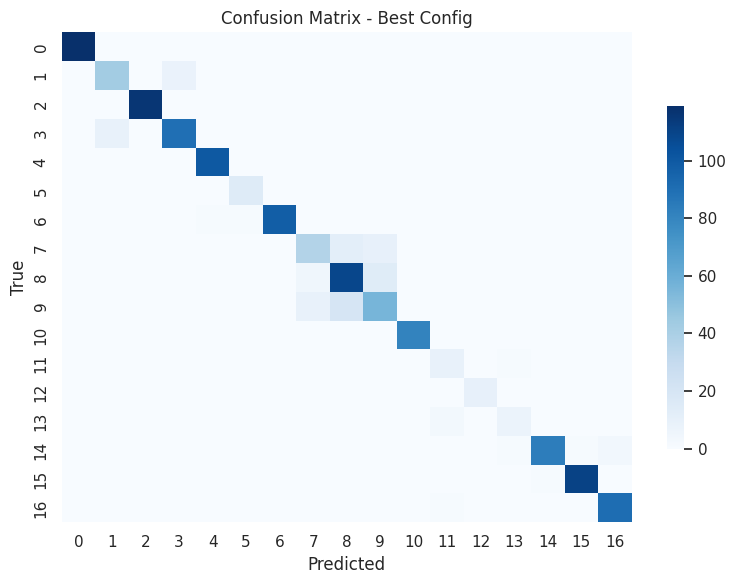

Saved confusion matrix to /content/drive/MyDrive/CropDisease/outputs/mobilenet/confusion_matrix.png


/tmp/ipykernel_620/2736573220.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=CLASS_NAMES, y=class_f1, palette='crest', edgecolor='black')


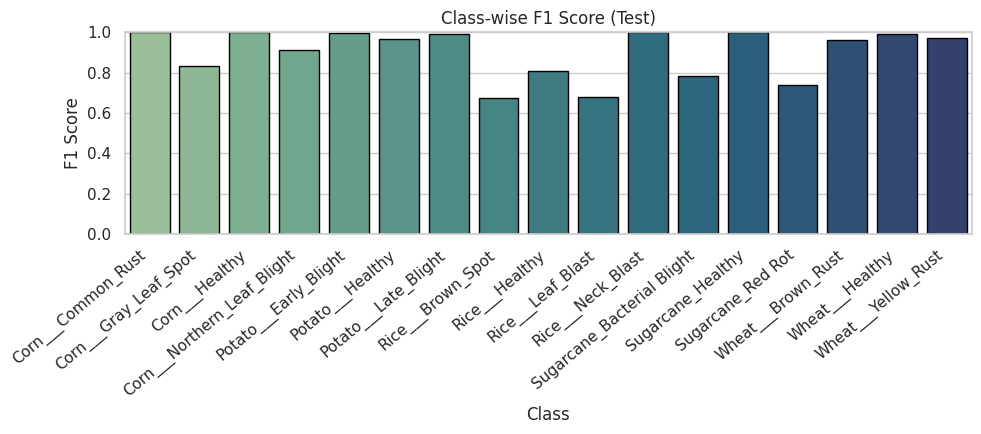

Saved class-wise F1 to /content/drive/MyDrive/CropDisease/outputs/mobilenet/classwise_f1.png


/tmp/ipykernel_620/2736573220.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(summary_scores.keys()), y=list(summary_scores.values()), palette='mako', edgecolor='black')


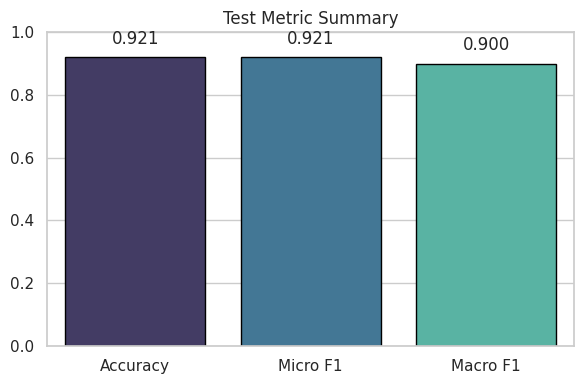

Saved metric summary to /content/drive/MyDrive/CropDisease/outputs/mobilenet/metric_summary.png


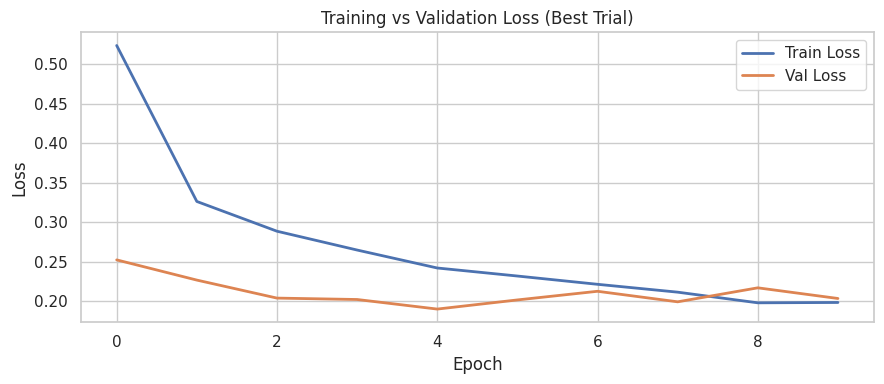

Saved loss curves to /content/drive/MyDrive/CropDisease/outputs/mobilenet/best_loss_curves.png


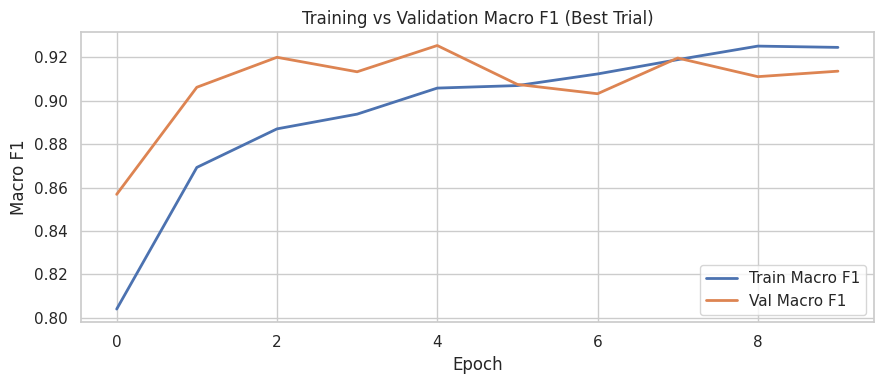

Saved macro F1 curves to /content/drive/MyDrive/CropDisease/outputs/mobilenet/best_macro_f1_curves.png


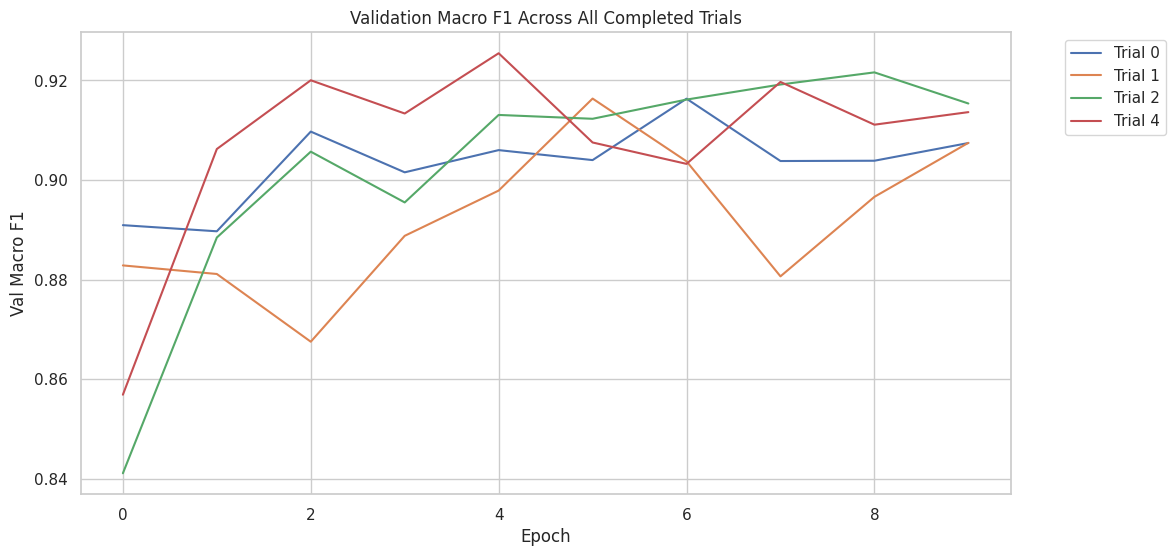

Saved all-trial macro F1 curves to /content/drive/MyDrive/CropDisease/outputs/mobilenet/all_trials_macro_f1_curves.png


In [8]:
# Load best model and evaluate on test set
best_trial = study.best_trial
best_path = best_trial.user_attrs['ckpt_path']
best_history = best_trial.user_attrs['history']
print('Loading best checkpoint:', best_path)

best_model = build_mobilenet(best_trial.params['model'], best_trial.params['dropout'])
state = torch.load(best_path, map_location=DEVICE)
best_model.load_state_dict(state['model_state'])
best_model.eval()

test_loader = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=0, pin_memory=True)
criterion = nn.CrossEntropyLoss()
t_loss, t_acc, t_macro, t_micro, preds, labels = run_epoch(best_model, test_loader, criterion, optimizer=None)
print({'test_loss': t_loss, 'test_acc': t_acc, 'test_macro_f1': t_macro, 'test_micro_f1': t_micro})

sns.set_theme(style='whitegrid')

metrics_path = os.path.join(OUT_DIR, 'best_metrics.json')
with open(metrics_path, 'w') as f:
    json.dump({
        'best_trial': best_trial.number,
        'best_params': best_trial.params,
        'val_macro': best_trial.user_attrs['best_macro'],
        'test_loss': t_loss,
        'test_acc': t_acc,
        'test_macro_f1': t_macro,
        'test_micro_f1': t_micro
    }, f, indent=2)
print('Saved metrics to', metrics_path)

cm = confusion_matrix(labels, preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=False, cmap='Blues', fmt='d', cbar_kws={'shrink': 0.7})
plt.title('Confusion Matrix - Best Config')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
cm_path = os.path.join(OUT_DIR, 'confusion_matrix.png')
plt.savefig(cm_path, dpi=300, bbox_inches='tight')
plt.show()
print('Saved confusion matrix to', cm_path)

class_f1 = f1_score(labels, preds, average=None, labels=list(range(NUM_CLASSES)), zero_division=0)
plt.figure(figsize=(10, 4.5))
sns.barplot(x=CLASS_NAMES, y=class_f1, palette='crest', edgecolor='black')
plt.ylabel('F1 Score')
plt.xlabel('Class')
plt.title('Class-wise F1 Score (Test)')
plt.xticks(rotation=40, ha='right')
plt.ylim(0, 1)
plt.tight_layout()
class_f1_path = os.path.join(OUT_DIR, 'classwise_f1.png')
plt.savefig(class_f1_path, dpi=300, bbox_inches='tight')
plt.show()
print('Saved class-wise F1 to', class_f1_path)

summary_scores = {
    'Accuracy': t_acc,
    'Micro F1': t_micro,
    'Macro F1': t_macro
}
plt.figure(figsize=(6, 4))
sns.barplot(x=list(summary_scores.keys()), y=list(summary_scores.values()), palette='mako', edgecolor='black')
plt.ylim(0, 1)
plt.title('Test Metric Summary')
for idx, val in enumerate(summary_scores.values()):
    plt.text(idx, min(val + 0.03, 1.02), f"{val:.3f}", ha='center', va='bottom')
plt.tight_layout()
metric_summary_path = os.path.join(OUT_DIR, 'metric_summary.png')
plt.savefig(metric_summary_path, dpi=300, bbox_inches='tight')
plt.show()
print('Saved metric summary to', metric_summary_path)

plt.figure(figsize=(9, 4))
plt.plot(best_history['train_loss'], label='Train Loss', linewidth=2)
plt.plot(best_history['val_loss'], label='Val Loss', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss (Best Trial)')
plt.legend()
plt.tight_layout()
loss_curve_path = os.path.join(OUT_DIR, 'best_loss_curves.png')
plt.savefig(loss_curve_path, dpi=300, bbox_inches='tight')
plt.show()
print('Saved loss curves to', loss_curve_path)

plt.figure(figsize=(9, 4))
plt.plot(best_history['train_macro'], label='Train Macro F1', linewidth=2)
plt.plot(best_history['val_macro'], label='Val Macro F1', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Macro F1')
plt.title('Training vs Validation Macro F1 (Best Trial)')
plt.legend()
plt.tight_layout()
macro_curve_path = os.path.join(OUT_DIR, 'best_macro_f1_curves.png')
plt.savefig(macro_curve_path, dpi=300, bbox_inches='tight')
plt.show()
print('Saved macro F1 curves to', macro_curve_path)

plt.figure(figsize=(12, 6))
for trial in study.trials:
    if trial.state.name == 'COMPLETE' and 'history' in trial.user_attrs:
        hist = trial.user_attrs['history']
        if 'val_macro' in hist:
            plt.plot(hist['val_macro'], label=f"Trial {trial.number}")
plt.xlabel('Epoch')
plt.ylabel('Val Macro F1')
plt.title('Validation Macro F1 Across All Completed Trials')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
all_f1_curve_path = os.path.join(OUT_DIR, 'all_trials_macro_f1_curves.png')
plt.savefig(all_f1_curve_path, dpi=300, bbox_inches='tight')
plt.show()
print('Saved all-trial macro F1 curves to', all_f1_curve_path)

In [9]:
# Save the best model as structural formats
import joblib

full_model_path = os.path.join(OUT_DIR, 'best_mobilenet_full_model.pth')
torch.save(best_model, full_model_path)
print(f"Saved full PyTorch model to: {full_model_path}")

joblib_path = os.path.join(OUT_DIR, 'best_mobilenet_weights.pkl')
joblib.dump(best_model.state_dict(), joblib_path)
print(f"Saved PyTorch weights via joblib to: {joblib_path}")

Saved full PyTorch model to: /content/drive/MyDrive/CropDisease/outputs/mobilenet/best_mobilenet_full_model.pth
Saved PyTorch weights via joblib to: /content/drive/MyDrive/CropDisease/outputs/mobilenet/best_mobilenet_weights.pkl
